# 03 — Backtest: Fair Value Mean Reversion

In [1]:
from datetime import datetime, timedelta, timezone
from src.layer1_research.backtesting.config import BacktestConfig
from src.layer1_research.backtesting.runner import BacktestRunner
from src.layer1_research.backtesting.strategies.examples.fair_value_mean_reversion import (
    FairValueMeanReversionStrategy,
)
from src.layer1_research.backtesting.execution.fill_model import PredictionMarketFillConfig
from src.layer1_research.backtesting.reporting.cli_report import print_report

## Config

In [2]:
config = BacktestConfig(
    catalog_path="data/catalog",
    start=datetime(2024, 6, 1, tzinfo=timezone.utc),
    end=datetime(2024, 9, 1, tzinfo=timezone.utc),
    strategy_name="fair_value_mr",
    starting_capital=10_000.0,
    data_mode="trade",
    fee_rate_bps=100,
    position_sizer="fixed_fractional",
    fill_model=PredictionMarketFillConfig(base_spread_pct=0.04),
    strategy_params={"lookback_trades": 20, "entry_threshold": 0.05},
)

## Run

In [3]:
result = BacktestRunner(config).run(FairValueMeanReversionStrategy)
print_report(result.metrics())

1970-01-01T00:00:00.000000000Z [WARN] BACKTESTER-001.FairValueMeanReversionStrategy: The `Strategy.on_stop` handler was called when not overridden. It's expected that any actions required when stopping the strategy occur here, such as unsubscribing from data

  Backtest results
  Total Return:                0.00%
  Sharpe Ratio:                 nan
  Sortino Ratio:                nan
  Max Drawdown:                0.00%
  Calmar Ratio:                0.00
  Total Trades:                   0
  Win Rate:                    0.0%
  Avg Win:             $       0.00
  Avg Loss:            $       0.00
  Profit Factor:               0.00
  Total Fees:          $       0.00
  Fee Drag:                    0.0%
  Avg Slippage:               0.0 bps
  Avg Edge @ Order:          0.0000
  Edge Realization:            0.00



## Plots

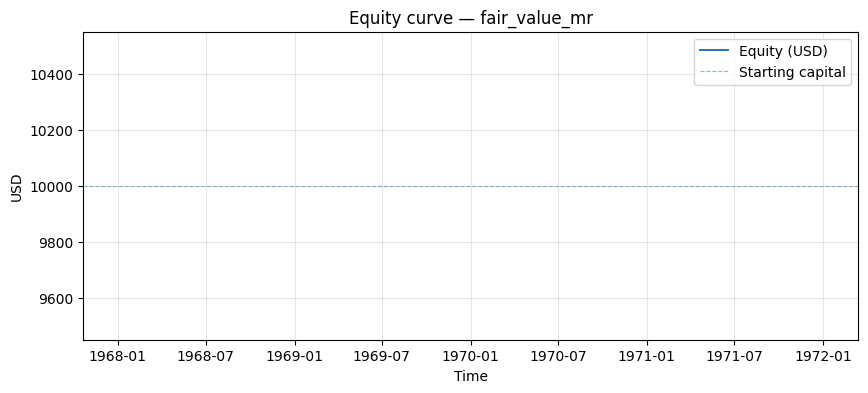

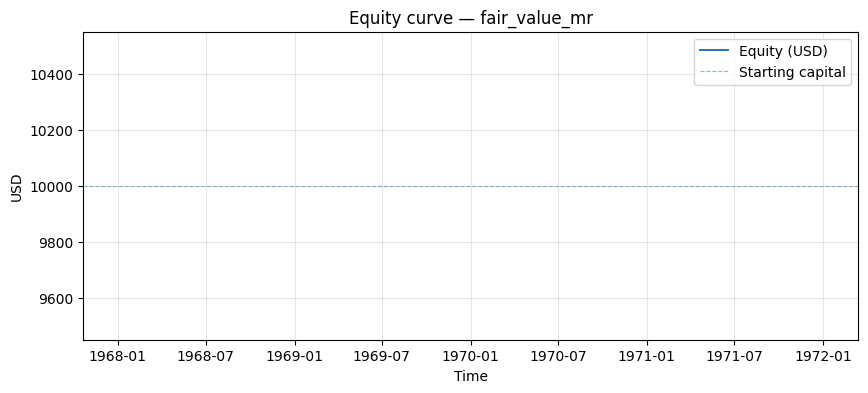

In [4]:
result.plot_equity_curve()

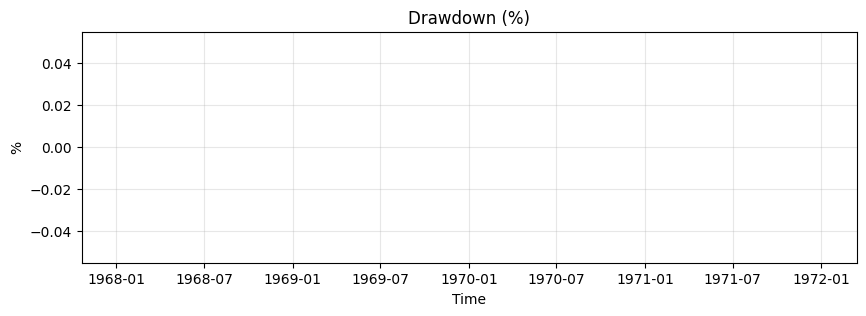

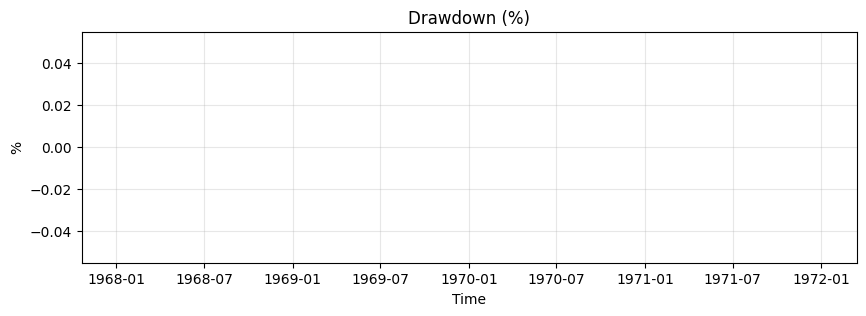

In [5]:
result.plot_drawdown()

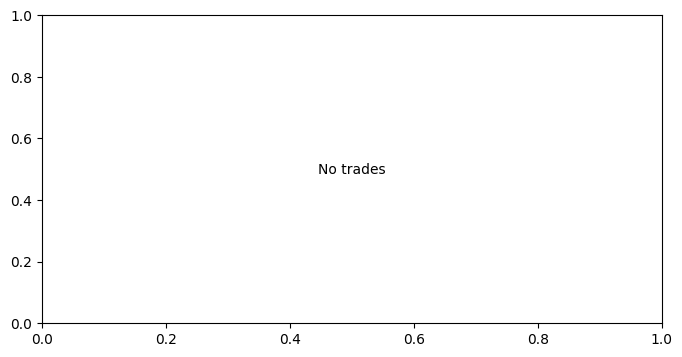

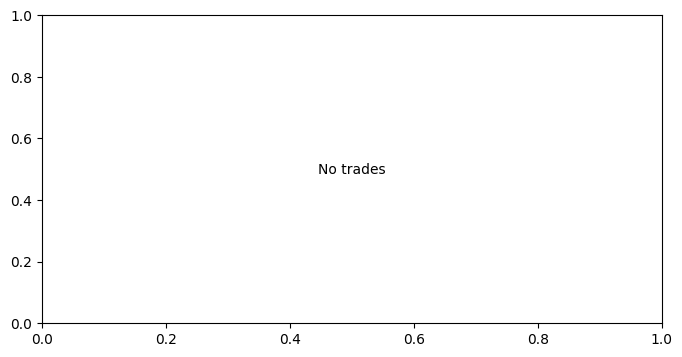

In [6]:
result.plot_pnl_histogram()

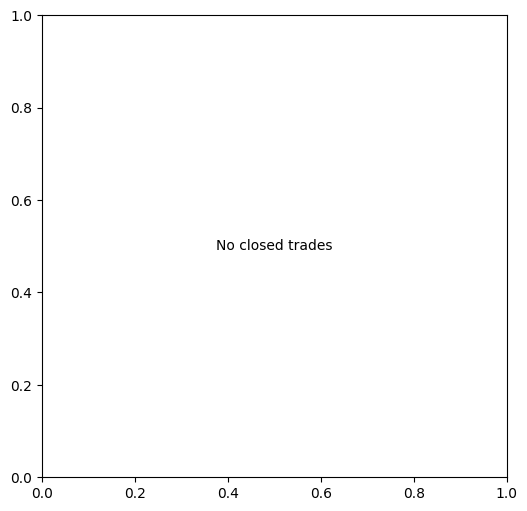

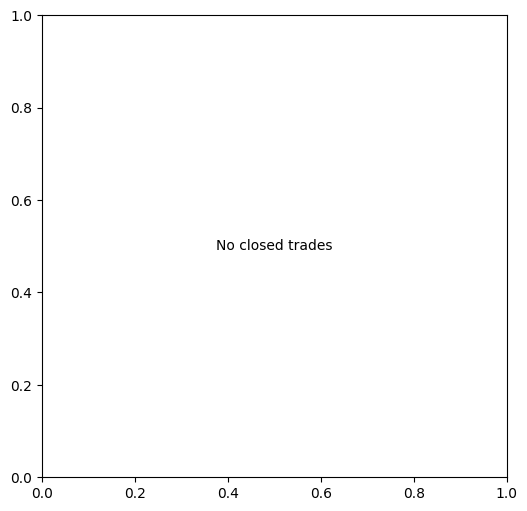

In [7]:
result.plot_edge_calibration()

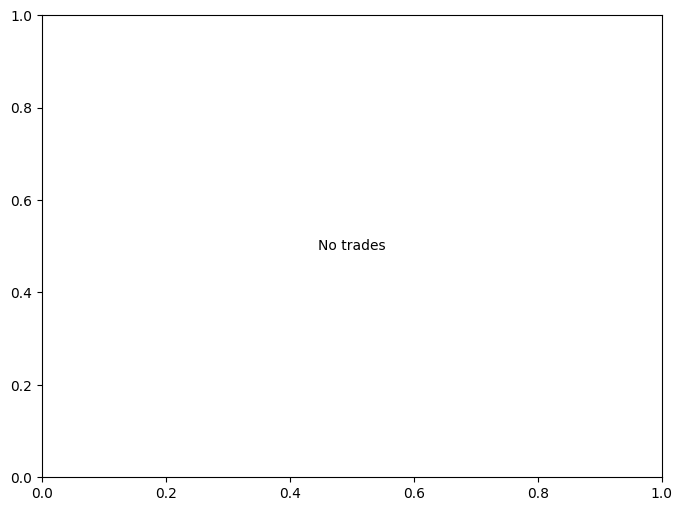

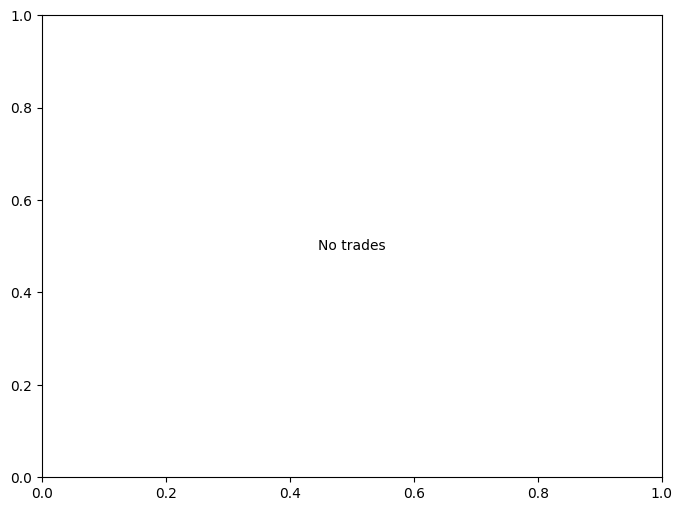

In [8]:
result.plot_per_market_pnl()

## Inspect trades and signals

In [9]:
result.trades.head(20)

,instrument_id,direction,entry_ts,exit_ts,entry_price,exit_price,size,fees,gross_pnl,net_pnl,edge_at_entry,slippage_bps,signal_confidence,realized_edge


In [10]:
result.signals.head(20)

,ts,instrument_id,direction,market_price,confidence,target_price,size,client_order_id,edge_at_order


## Optional: log to MLflow

In [11]:
# run_id = result.to_mlflow(run_name=f"fair_value_mr_{config.start.date()}_{config.end.date()}")
# print(f"MLflow run: {run_id}")